# **Data Collection Using Pytrends**

In [1]:
!pip install pytrends

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
pytrends = TrendReq(hl='en-US', tz=360)  #hl='en-US' means language is English.tz=360 is the timezone offset

In [4]:
keywords = ['Amazon Affiliate Marketing','Pinterest Affiliate Marketing','Make Money Pinterest','Amazon Associates','Affiliate Marketing']
pytrends.build_payload(kw_list=keywords,cat=0,timeframe='today 5-y',geo='IN')

df_trends=pytrends.interest_over_time()
df_trends=df_trends.drop(columns=['isPartial'])

print("Data fetched successfuilly!")
print(f"Shape of data: {df_trends.shape}")
print(df_trends.head())

Data fetched successfuilly!
Shape of data: (261, 5)
            Amazon Affiliate Marketing  Pinterest Affiliate Marketing  \
date                                                                    
2021-04-18                           7                              0   
2021-04-25                           6                              0   
2021-05-02                           7                              0   
2021-05-09                           7                              0   
2021-05-16                           8                              0   

            Make Money Pinterest  Amazon Associates  Affiliate Marketing  
date                                                                      
2021-04-18                     0                 11                   55  
2021-04-25                     0                 13                   60  
2021-05-02                     0                 13                   65  
2021-05-09                     1                 15          

In [5]:
df_trends.to_csv('amazon_pinterest_trends.csv')
print("Data saved as 'amazon_pinterest_trends.csv'")
print(df_trends.tail())

Data saved as 'amazon_pinterest_trends.csv'
            Amazon Affiliate Marketing  Pinterest Affiliate Marketing  \
date                                                                    
2026-03-15                           3                              2   
2026-03-22                           3                              2   
2026-03-29                           3                              2   
2026-04-05                           3                              2   
2026-04-12                           2                              1   

            Make Money Pinterest  Amazon Associates  Affiliate Marketing  
date                                                                      
2026-03-15                     2                 34                   23  
2026-03-22                     2                 38                   20  
2026-03-29                     2                 33                   20  
2026-04-05                     2                 28                  

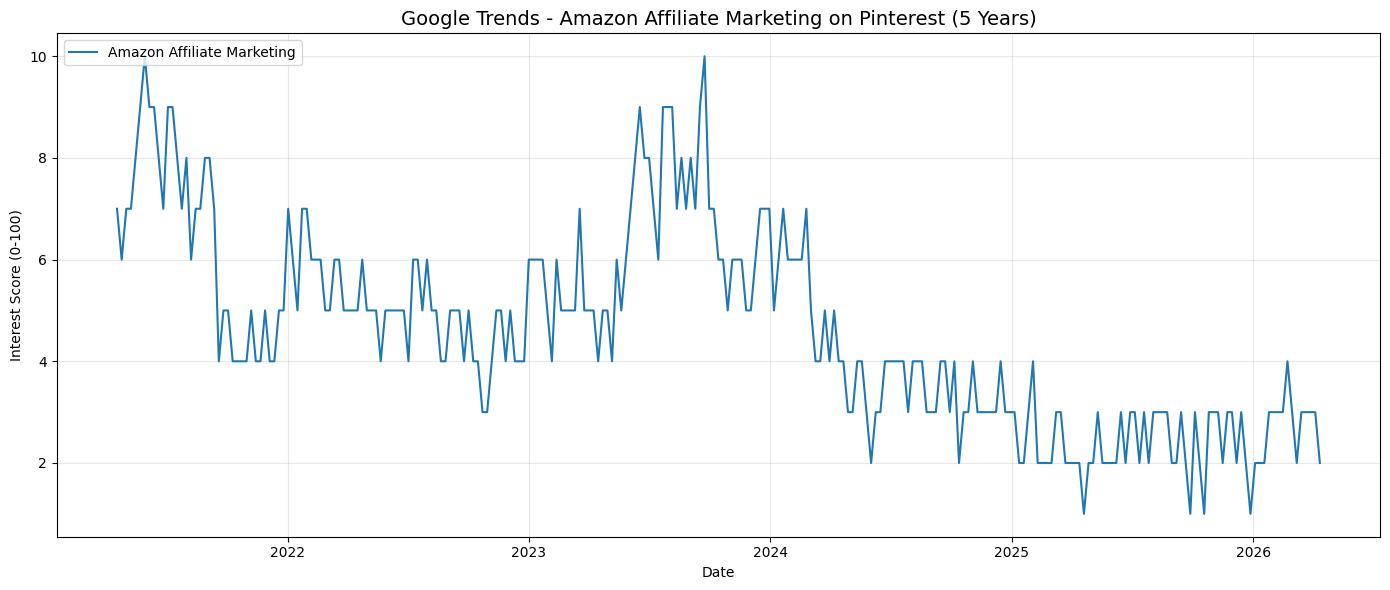

Chart displayed


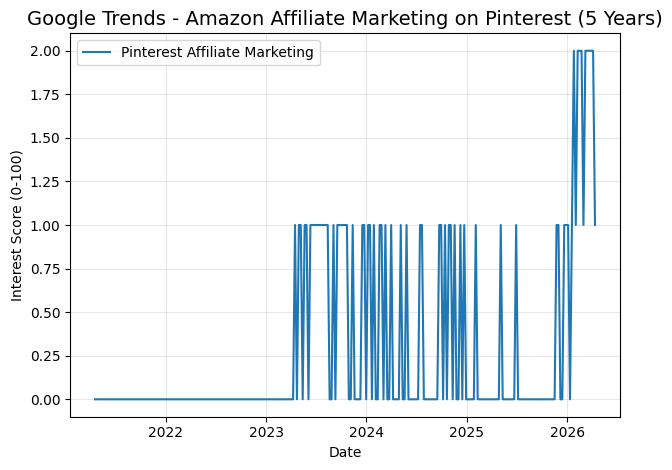

Chart displayed


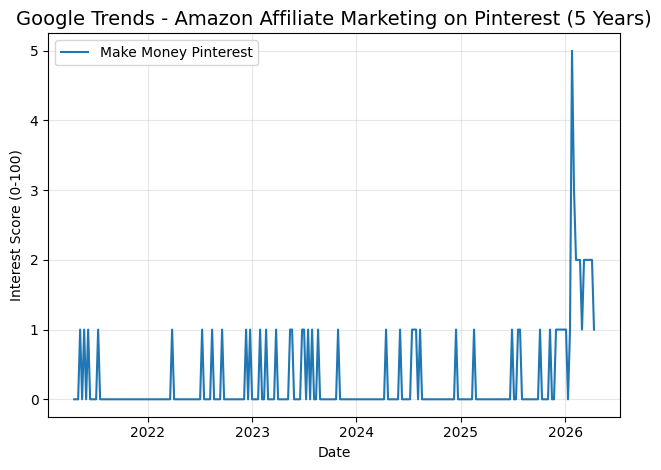

Chart displayed


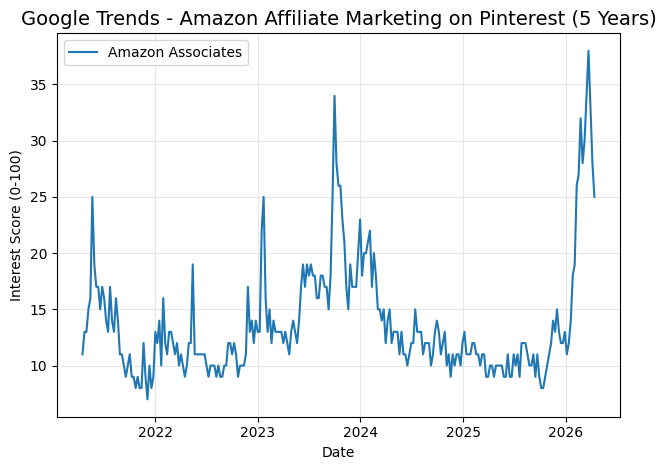

Chart displayed


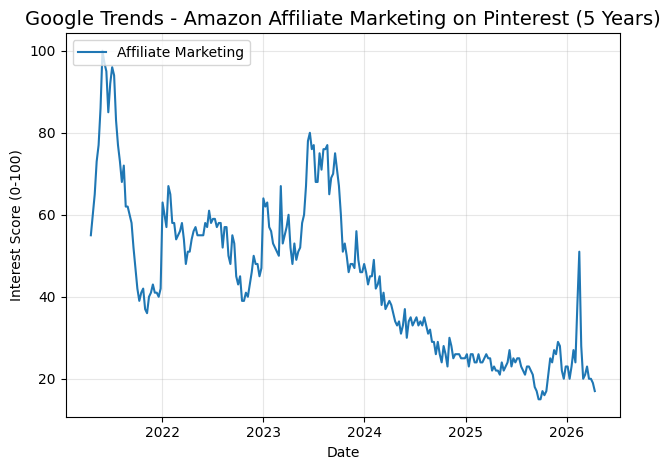

Chart displayed


In [6]:
plt.figure(figsize=(14,6))
for column in df_trends.columns:
  plt.plot(df_trends.index, df_trends[column], label=column)

  plt.title('Google Trends - Amazon Affiliate Marketing on Pinterest (5 Years)', fontsize=14)
  plt.xlabel('Date')
  plt.ylabel('Interest Score (0-100)')
  plt.legend(loc='upper left')
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()

  print("Chart displayed")

# **Checking Basic Info & Missing Values**

In [7]:
print("="*50)
print("DataSet Info")
print("="*50)
print(df_trends.info())

print("\n"+"="*50)
print("Missing Values")
print("="*50)
print(df_trends.isnull().sum())

print("\n"+"="*50)
print("Data Types")
print("="*50)
print(df_trends.dtypes)

DataSet Info
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261 entries, 2021-04-18 to 2026-04-12
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Amazon Affiliate Marketing     261 non-null    int64
 1   Pinterest Affiliate Marketing  261 non-null    int64
 2   Make Money Pinterest           261 non-null    int64
 3   Amazon Associates              261 non-null    int64
 4   Affiliate Marketing            261 non-null    int64
dtypes: int64(5)
memory usage: 12.2 KB
None

Missing Values
Amazon Affiliate Marketing       0
Pinterest Affiliate Marketing    0
Make Money Pinterest             0
Amazon Associates                0
Affiliate Marketing              0
dtype: int64

Data Types
Amazon Affiliate Marketing       int64
Pinterest Affiliate Marketing    int64
Make Money Pinterest             int64
Amazon Associates                int64
Affiliate Marketing              int64
dty

In [8]:
print("="*50)
print("Basic Statistics")
print("="*50)
print(df_trends.describe())

print("\n"+"="*50)
print("Numpy Calculations")
print("="*50)

for column in df_trends.columns:
    print(f"\n Keyword: {column}")
    print(f"   Mean  (Average) : {np.mean(df_trends[column]):.2f}")
    print(f"   Max   (Peak)    : {np.max(df_trends[column]):.2f}")
    print(f"   Min   (Lowest)  : {np.min(df_trends[column]):.2f}")
    print(f"   Std   (Variation): {np.std(df_trends[column]):.2f}")

Basic Statistics
       Amazon Affiliate Marketing  Pinterest Affiliate Marketing  \
count                  261.000000                     261.000000   
mean                     4.613027                       0.283525   
std                      1.968908                       0.522638   
min                      1.000000                       0.000000   
25%                      3.000000                       0.000000   
50%                      4.000000                       0.000000   
75%                      6.000000                       0.000000   
max                     10.000000                       2.000000   

       Make Money Pinterest  Amazon Associates  Affiliate Marketing  
count            261.000000         261.000000           261.000000  
mean               0.256705          13.770115            44.249042  
std                0.594205           5.165048            18.858666  
min                0.000000           7.000000            15.000000  
25%                0

In [9]:
print("=" * 50)
print(" KEYWORD RANKING BY AVERAGE INTEREST")
print("=" * 50)

# Calculate average interest for each keyword
avg_interest = df_trends.mean().sort_values(ascending=False)

print(avg_interest)

print("\n Most Trending Keyword:", avg_interest.idxmax())
print(" Least Trending Keyword:", avg_interest.idxmin())

 KEYWORD RANKING BY AVERAGE INTEREST
Affiliate Marketing              44.249042
Amazon Associates                13.770115
Amazon Affiliate Marketing        4.613027
Pinterest Affiliate Marketing     0.283525
Make Money Pinterest              0.256705
dtype: float64

 Most Trending Keyword: Affiliate Marketing
 Least Trending Keyword: Make Money Pinterest


In [10]:
#1. Total interest per week (sum of all keywords)
df_trends['Total_Interest'] = df_trends.sum(axis=1)

# 2. Average interest per week
df_trends['Weekly_Average'] = df_trends.mean(axis=1)

# 3. Dominant keyword that week (which keyword had highest score)
df_trends['Top_Keyword'] = df_trends[
    ['Amazon Affiliate Marketing',
     'Pinterest Affiliate Marketing',
     'Make Money Pinterest',
     'Amazon Associates',
     'Affiliate Marketing']
].idxmax(axis=1)

# 4. Label the trend direction (going up or down)
df_trends['Trend_Direction'] = np.where(
    df_trends['Total_Interest'] > df_trends['Total_Interest'].shift(1),
    '📈 UP', '📉 DOWN'
)

print("✅ New columns added!")
print(df_trends.head(10))

✅ New columns added!
            Amazon Affiliate Marketing  Pinterest Affiliate Marketing  \
date                                                                    
2021-04-18                           7                              0   
2021-04-25                           6                              0   
2021-05-02                           7                              0   
2021-05-09                           7                              0   
2021-05-16                           8                              0   
2021-05-23                           9                              0   
2021-05-30                          10                              0   
2021-06-06                           9                              0   
2021-06-13                           9                              0   
2021-06-20                           8                              0   

            Make Money Pinterest  Amazon Associates  Affiliate Marketing  \
date                      

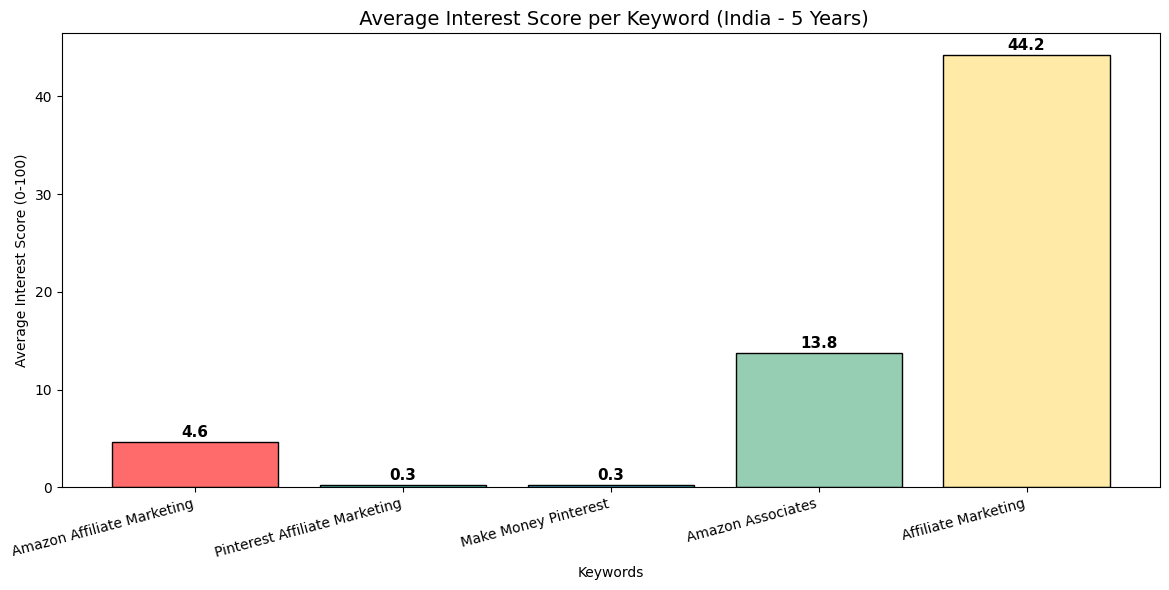

 Bar chart displayed!


In [11]:
avg_interest = df_trends[['Amazon Affiliate Marketing',
                           'Pinterest Affiliate Marketing',
                           'Make Money Pinterest',
                           'Amazon Associates',
                           'Affiliate Marketing']].mean()

plt.figure(figsize=(12, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

bars = plt.bar(avg_interest.index, avg_interest.values, color=colors, edgecolor='black')

# Add value labels on bars
for bar, value in zip(bars, avg_interest.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{value:.1f}',
             ha='center', fontsize=11, fontweight='bold')

plt.title(' Average Interest Score per Keyword (India - 5 Years)', fontsize=14)
plt.xlabel('Keywords')
plt.ylabel('Average Interest Score (0-100)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(" Bar chart displayed!")

In [12]:
df_trends.to_csv('cleaned_trends_data.csv')

print(" Cleaned data saved as 'cleaned_trends_data.csv'")
print(f" Final Shape: {df_trends.shape}")
print(f" Columns: {list(df_trends.columns)}")

 Cleaned data saved as 'cleaned_trends_data.csv'
 Final Shape: (261, 9)
 Columns: ['Amazon Affiliate Marketing', 'Pinterest Affiliate Marketing', 'Make Money Pinterest', 'Amazon Associates', 'Affiliate Marketing', 'Total_Interest', 'Weekly_Average', 'Top_Keyword', 'Trend_Direction']


# **Trend Analysis & Sentiment Analysis**

In [13]:
df_trends['Year'] = df_trends.index.year
df_trends['Month'] = df_trends.index.month
df_trends['Month_Name'] = df_trends.index.strftime('%B')

# Group by year and get average interest
yearly_trend = df_trends.groupby('Year')[['Amazon Affiliate Marketing',
                                          'Pinterest Affiliate Marketing',
                                          'Make Money Pinterest',
                                          'Amazon Associates',
                                          'Affiliate Marketing']].mean()

print("=" * 50)
print(" YEARLY AVERAGE INTEREST")
print("=" * 50)
print(yearly_trend)

 YEARLY AVERAGE INTEREST
      Amazon Affiliate Marketing  Pinterest Affiliate Marketing  \
Year                                                              
2021                    6.405405                       0.000000   
2022                    5.000000                       0.000000   
2023                    6.377358                       0.471698   
2024                    3.942308                       0.365385   
2025                    2.365385                       0.134615   
2026                    2.733333                       1.533333   

      Make Money Pinterest  Amazon Associates  Affiliate Marketing  
Year                                                                
2021              0.108108          12.513514            62.540541  
2022              0.115385          11.384615            53.038462  
2023              0.207547          17.301887            59.943396  
2024              0.134615          13.288462            33.365385  
2025              0.2115

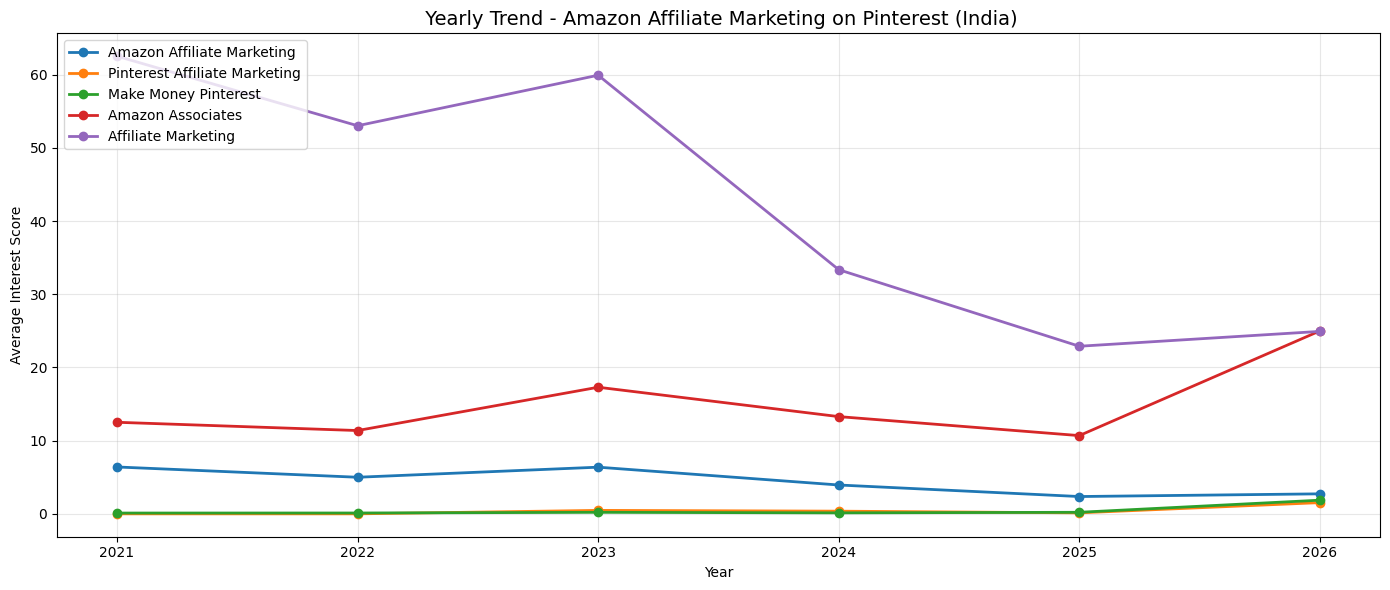

 Yearly trend chart displayed!


In [14]:
plt.figure(figsize=(14, 6))

for column in yearly_trend.columns:
    plt.plot(yearly_trend.index,
             yearly_trend[column],
             marker='o',
             linewidth=2,
             label=column)

plt.title(' Yearly Trend - Amazon Affiliate Marketing on Pinterest (India)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Interest Score')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(yearly_trend.index)
plt.tight_layout()
plt.show()

print(" Yearly trend chart displayed!")

In [15]:
print("=" * 50)
print(" PEAK PERIODS FOR EACH KEYWORD")
print("=" * 50)

keywords_list = ['Amazon Affiliate Marketing',
                 'Pinterest Affiliate Marketing',
                 'Make Money Pinterest',
                 'Amazon Associates',
                 'Affiliate Marketing']

for keyword in keywords_list:
    peak_date = df_trends[keyword].idxmax()
    peak_value = df_trends[keyword].max()
    low_date = df_trends[keyword].idxmin()
    low_value = df_trends[keyword].min()

    print(f"\n {keyword}")
    print(f"    Peak  : {peak_date.strftime('%B %Y')} (Score: {peak_value})")
    print(f"     Lowest: {low_date.strftime('%B %Y')} (Score: {low_value})")

 PEAK PERIODS FOR EACH KEYWORD

 Amazon Affiliate Marketing
    Peak  : May 2021 (Score: 10)
     Lowest: April 2025 (Score: 1)

 Pinterest Affiliate Marketing
    Peak  : January 2026 (Score: 2)
     Lowest: April 2021 (Score: 0)

 Make Money Pinterest
    Peak  : January 2026 (Score: 5)
     Lowest: April 2021 (Score: 0)

 Amazon Associates
    Peak  : March 2026 (Score: 38)
     Lowest: December 2021 (Score: 7)

 Affiliate Marketing
    Peak  : May 2021 (Score: 100)
     Lowest: September 2025 (Score: 15)


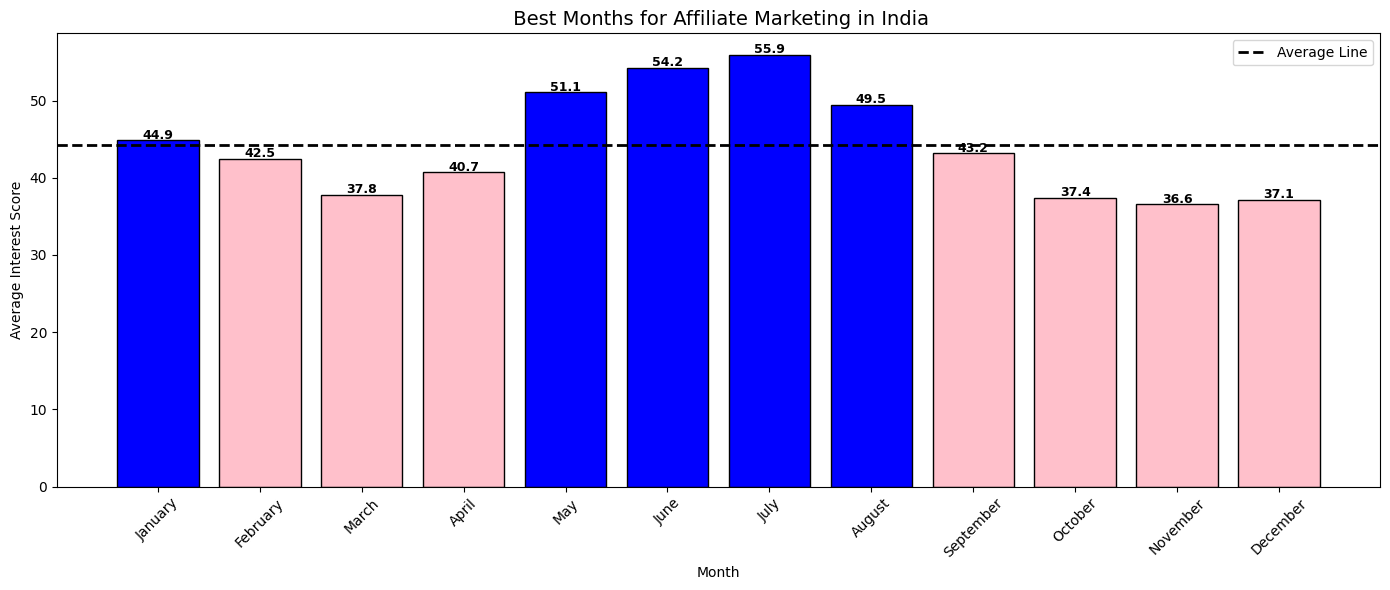

 Monthly seasonality chart displayed!

 Best Month : July (Score: 55.9)
 Worst Month: November (Score: 36.6)


In [16]:
monthly_avg = df_trends.groupby('Month_Name')['Affiliate Marketing'].mean()

# Sort by month order
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_avg = monthly_avg.reindex(month_order)

plt.figure(figsize=(14, 6))
colors = ['blue' if x > monthly_avg.mean() else 'pink' for x in monthly_avg.values]

bars = plt.bar(monthly_avg.index, monthly_avg.values, color=colors, edgecolor='black')

for bar, value in zip(bars, monthly_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{value:.1f}',
             ha='center', fontsize=9, fontweight='bold')

plt.axhline(y=monthly_avg.mean(), color='black',
            linestyle='--', linewidth=2, label='Average Line')

plt.title(' Best Months for Affiliate Marketing in India', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Interest Score')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print(" Monthly seasonality chart displayed!")
print(f"\n Best Month : {monthly_avg.idxmax()} (Score: {monthly_avg.max():.1f})")
print(f" Worst Month: {monthly_avg.idxmin()} (Score: {monthly_avg.min():.1f})")

In [17]:
print("=" * 50)
print(" SENTIMENT ANALYSIS OF KEYWORDS")
print("=" * 50)

keywords_list = ['Amazon Affiliate Marketing',
                 'Pinterest Affiliate Marketing',
                 'Make Money Pinterest',
                 'Amazon Associates',
                 'Affiliate Marketing']

sentiment_results = []

for keyword in keywords_list:
    avg_score = df_trends[keyword].mean()
    max_score = df_trends[keyword].max()
    recent_avg = df_trends[keyword].tail(12).mean()  # Last 3 months
    older_avg = df_trends[keyword].head(12).mean()   # First 3 months

    # Calculate trend direction
    trend_change = recent_avg - older_avg

    # Sentiment based on average score
    if avg_score >= 20:
        sentiment = " POSITIVE"
        polarity = round(avg_score / 100, 3)
    elif avg_score >= 5:
        sentiment = " NEUTRAL"
        polarity = 0.0
    else:
        sentiment = " NEGATIVE"
        polarity = round(-1 * (1 - avg_score / 10), 3)

    # Trend momentum
    if trend_change > 2:
        momentum = " GROWING"
    elif trend_change < -2:
        momentum = " DECLINING"
    else:
        momentum = " STABLE"

    sentiment_results.append({
        'Keyword': keyword,
        'Avg_Score': round(avg_score, 2),
        'Max_Score': max_score,
        'Polarity': polarity,
        'Sentiment': sentiment,
        'Momentum': momentum,
        'Trend_Change': round(trend_change, 2)
    })

    print(f"\n {keyword}")
    print(f"   Sentiment : {sentiment}")
    print(f"   Momentum  : {momentum}")
    print(f"   Avg Score : {avg_score:.2f}")
    print(f"   Max Score : {max_score}")
    print(f"   Trend Change: {trend_change:+.2f}")

df_sentiment = pd.DataFrame(sentiment_results)
print("\n Sentiment Analysis Complete!")
print(df_sentiment)

 SENTIMENT ANALYSIS OF KEYWORDS

 Amazon Affiliate Marketing
   Sentiment :  NEGATIVE
   Momentum  :  DECLINING
   Avg Score : 4.61
   Max Score : 10
   Trend Change: -5.08

 Pinterest Affiliate Marketing
   Sentiment :  NEGATIVE
   Momentum  :  STABLE
   Avg Score : 0.28
   Max Score : 2
   Trend Change: +1.75

 Make Money Pinterest
   Sentiment :  NEGATIVE
   Momentum  :  STABLE
   Avg Score : 0.26
   Max Score : 5
   Trend Change: +1.92

 Amazon Associates
   Sentiment :  NEUTRAL
   Momentum  :  GROWING
   Avg Score : 13.77
   Max Score : 38
   Trend Change: +12.00

 Affiliate Marketing
   Sentiment :  POSITIVE
   Momentum  :  DECLINING
   Avg Score : 44.25
   Max Score : 100
   Trend Change: -56.08

 Sentiment Analysis Complete!
                         Keyword  Avg_Score  Max_Score  Polarity  Sentiment  \
0     Amazon Affiliate Marketing       4.61         10    -0.539   NEGATIVE   
1  Pinterest Affiliate Marketing       0.28          2    -0.972   NEGATIVE   
2           Make Mon

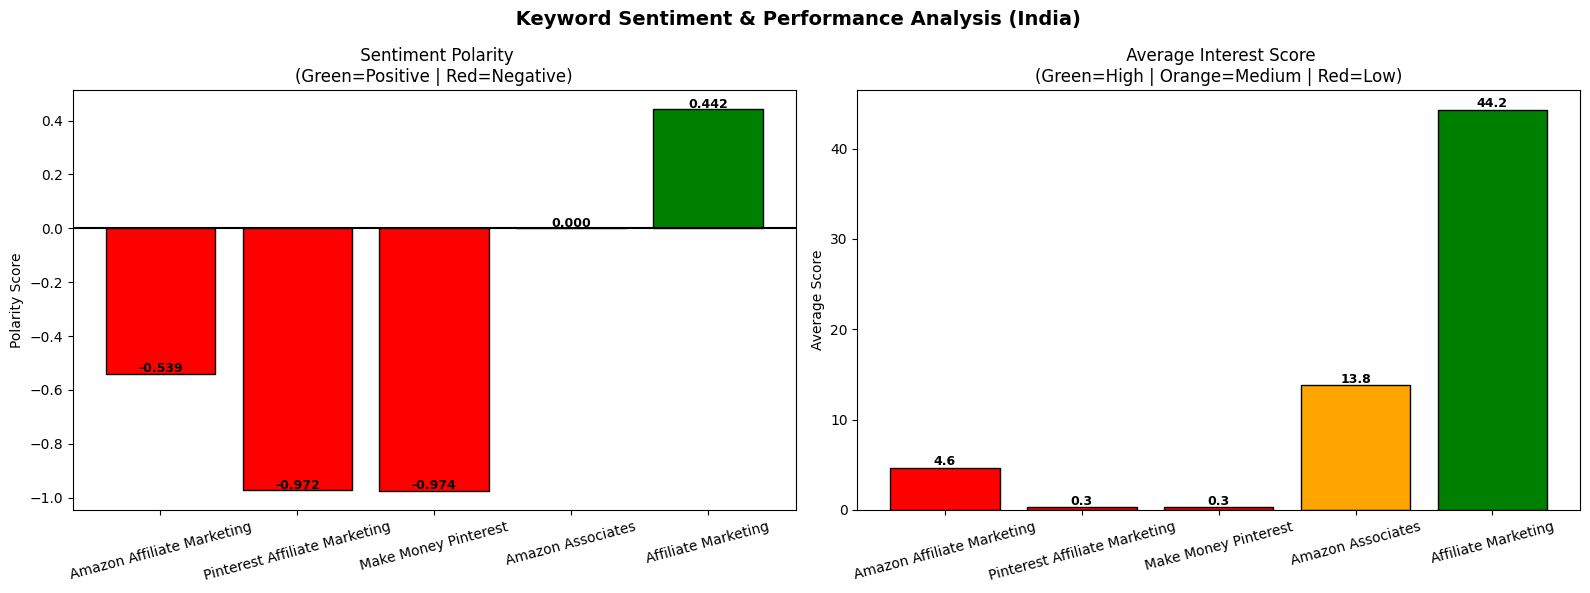

 Updated sentiment chart displayed!


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 - Sentiment Polarity
colors1 = ['green' if x > 0 else 'red' if x < 0 else 'gray'
           for x in df_sentiment['Polarity']]

bars = axes[0].bar(df_sentiment['Keyword'],
                   df_sentiment['Polarity'],
                   color=colors1, edgecolor='black')

for bar, value in zip(bars, df_sentiment['Polarity']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{value:.3f}',
                 ha='center', fontsize=9, fontweight='bold')

axes[0].set_title(' Sentiment Polarity\n(Green=Positive | Red=Negative)', fontsize=12)
axes[0].set_ylabel('Polarity Score')
axes[0].tick_params(axis='x', rotation=15)
axes[0].axhline(y=0, color='black', linewidth=1.5)

# Chart 2 - Average Interest Score
colors2 = ['green' if x >= 20 else 'orange' if x >= 5 else 'red'
           for x in df_sentiment['Avg_Score']]

bars2 = axes[1].bar(df_sentiment['Keyword'],
                    df_sentiment['Avg_Score'],
                    color=colors2, edgecolor='black')

for bar, value in zip(bars2, df_sentiment['Avg_Score']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{value:.1f}',
                 ha='center', fontsize=9, fontweight='bold')

axes[1].set_title(' Average Interest Score\n(Green=High | Orange=Medium | Red=Low)', fontsize=12)
axes[1].set_ylabel('Average Score')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle(' Keyword Sentiment & Performance Analysis (India)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(" Updated sentiment chart displayed!")

In [ ]:
df_trends.to_csv('trend_analysis_data.csv')
df_sentiment.to_csv('sentiment_data.csv')

print(" Trend analysis data saved as 'trend_analysis_data.csv'")
print(" Sentiment data saved as 'sentiment_data.csv'")
print(f"\n Final Dataset Shape: {df_trends.shape}")
print(f" All Columns: {list(df_trends.columns)}")

# **Machine Learning Model**

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All ML libraries imported successfully!")

All ML libraries imported successfully!


In [20]:
df_ml = df_trends.copy()

# Features (X) - what we use to predict
features = ['Amazon Affiliate Marketing',
            'Pinterest Affiliate Marketing',
            'Make Money Pinterest',
            'Amazon Associates',
            'Year',
            'Month',
            'Total_Interest',
            'Weekly_Average']

# Target (y) - what we want to predict
target = 'Affiliate Marketing'

X = df_ml[features]
y = df_ml[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", features)
print("\nFirst 5 rows of features:")
print(X.head())

Features shape: (261, 8)
Target shape: (261,)

Feature columns: ['Amazon Affiliate Marketing', 'Pinterest Affiliate Marketing', 'Make Money Pinterest', 'Amazon Associates', 'Year', 'Month', 'Total_Interest', 'Weekly_Average']

First 5 rows of features:
            Amazon Affiliate Marketing  Pinterest Affiliate Marketing  \
date                                                                    
2021-04-18                           7                              0   
2021-04-25                           6                              0   
2021-05-02                           7                              0   
2021-05-09                           7                              0   
2021-05-16                           8                              0   

            Make Money Pinterest  Amazon Associates  Year  Month  \
date                                                               
2021-04-18                     0                 11  2021      4   
2021-04-25                     

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42     # For reproducibility
)

print("Training data size  :", X_train.shape[0], "weeks")
print("Testing data size   :", X_test.shape[0], "weeks")
print("\n80% of data is used to TRAIN the model")
print("20% of data is used to TEST the model accuracy")

Training data size  : 208 weeks
Testing data size   : 53 weeks

80% of data is used to TRAIN the model
20% of data is used to TEST the model accuracy


In [22]:
model = RandomForestRegressor(
    n_estimators=100,    # 100 decision trees
    max_depth=10,        # Maximum depth of each tree
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Model type  : Random Forest Regressor")
print("No of trees : 100")

Model trained successfully!
Model type  : Random Forest Regressor
No of trees : 100


In [23]:
y_pred = model.predict(X_test)

# Calculate accuracy metrics
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=" * 50)
print("MODEL ACCURACY RESULTS")
print("=" * 50)
print(f"R2 Score (Accuracy)     : {r2:.4f}  -> {r2*100:.2f}%")
print(f"Mean Absolute Error     : {mae:.4f}")
print(f"Root Mean Squared Error : {rmse:.4f}")
print("\nHow to read R2 Score:")
print("  1.00 = Perfect prediction")
print("  0.80 = 80% accurate (Good)")
print("  0.60 = 60% accurate (Acceptable)")
print("  Below 0.5 = Needs improvement")

MODEL ACCURACY RESULTS
R2 Score (Accuracy)     : 0.9860  -> 98.60%
Mean Absolute Error     : 1.4740
Root Mean Squared Error : 2.3578

How to read R2 Score:
  1.00 = Perfect prediction
  0.80 = 80% accurate (Good)
  0.60 = 60% accurate (Acceptable)
  Below 0.5 = Needs improvement


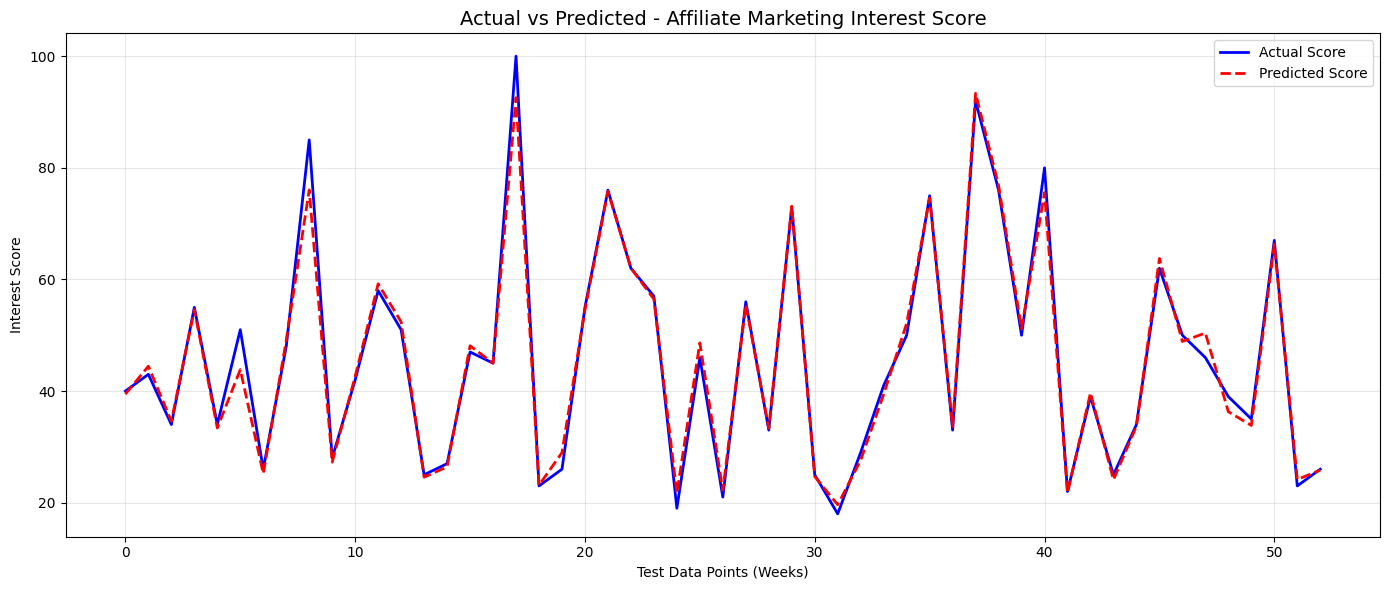

Actual vs Predicted chart displayed!


In [24]:
plt.figure(figsize=(14, 6))

plt.plot(range(len(y_test)),
         y_test.values,
         label='Actual Score',
         color='blue',
         linewidth=2)

plt.plot(range(len(y_test)),
         y_pred,
         label='Predicted Score',
         color='red',
         linewidth=2,
         linestyle='--')

plt.title('Actual vs Predicted - Affiliate Marketing Interest Score', fontsize=14)
plt.xlabel('Test Data Points (Weeks)')
plt.ylabel('Interest Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Actual vs Predicted chart displayed!")

FEATURE IMPORTANCE RANKING
                         Feature  Importance
4                           Year    0.355469
7                 Weekly_Average    0.305903
6                 Total_Interest    0.286609
0     Amazon Affiliate Marketing    0.028868
3              Amazon Associates    0.011614
5                          Month    0.010258
2           Make Money Pinterest    0.000784
1  Pinterest Affiliate Marketing    0.000495


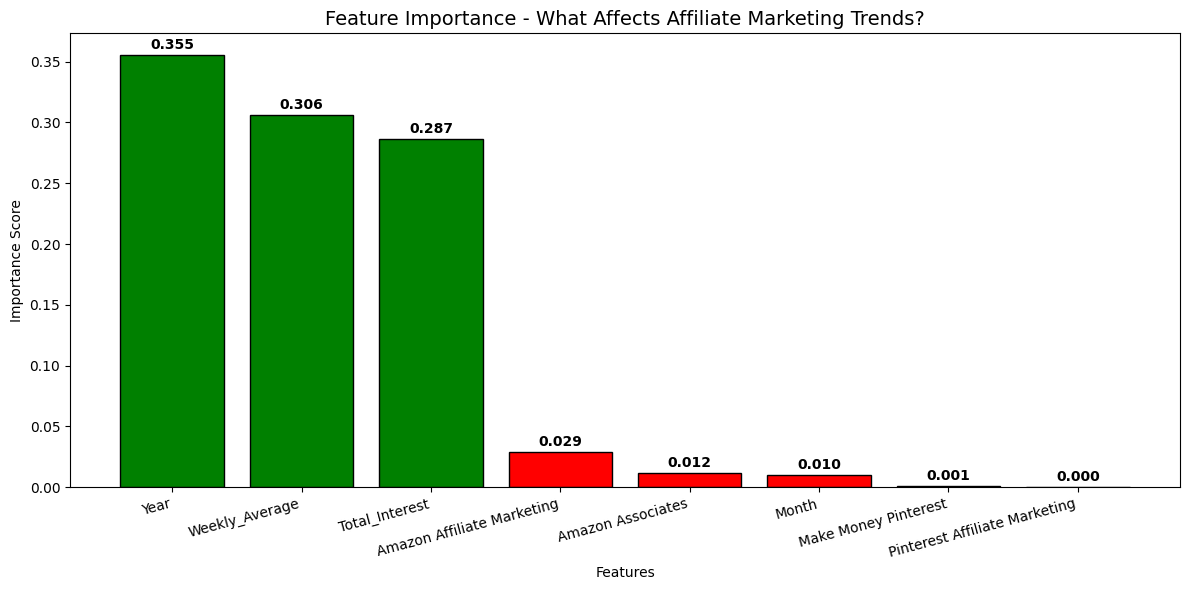

Feature importance chart displayed!


In [25]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("=" * 50)
print("FEATURE IMPORTANCE RANKING")
print("=" * 50)
print(feature_importance)

plt.figure(figsize=(12, 6))
colors = ['green' if x > 0.2 else 'orange' if x > 0.1 else 'red'
          for x in feature_importance['Importance']]

bars = plt.bar(feature_importance['Feature'],
               feature_importance['Importance'],
               color=colors,
               edgecolor='black')

for bar, value in zip(bars, feature_importance['Importance']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{value:.3f}',
             ha='center', fontsize=10, fontweight='bold')

plt.title('Feature Importance - What Affects Affiliate Marketing Trends?', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print("Feature importance chart displayed!")

FUTURE TREND PREDICTIONS (Next 12 Weeks)
Week  1 | 19 April 2026 | Predicted Score: 19.24
Week  2 | 26 April 2026 | Predicted Score: 19.24
Week  3 | 03 May 2026 | Predicted Score: 19.30
Week  4 | 10 May 2026 | Predicted Score: 19.30
Week  5 | 17 May 2026 | Predicted Score: 19.30
Week  6 | 24 May 2026 | Predicted Score: 19.30
Week  7 | 31 May 2026 | Predicted Score: 19.30
Week  8 | 07 June 2026 | Predicted Score: 19.27
Week  9 | 14 June 2026 | Predicted Score: 19.27
Week 10 | 21 June 2026 | Predicted Score: 19.27
Week 11 | 28 June 2026 | Predicted Score: 19.27
Week 12 | 05 July 2026 | Predicted Score: 19.31


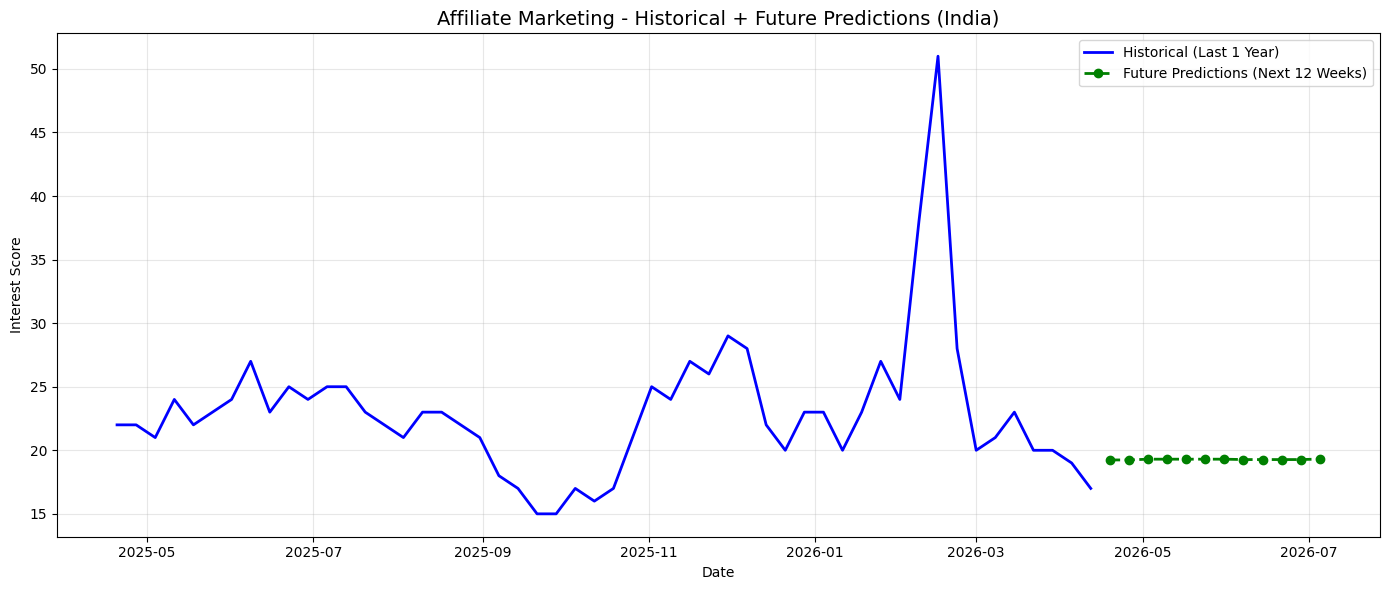

Future predictions chart displayed!


In [26]:
import datetime

print("=" * 50)
print("FUTURE TREND PREDICTIONS (Next 12 Weeks)")
print("=" * 50)

# Get the last row of data as base
last_row = X.iloc[-1].copy()

future_predictions = []
future_dates = []

for i in range(1, 13):
    future_date = df_trends.index[-1] + pd.Timedelta(weeks=i)
    future_dates.append(future_date)

    # Update month and year
    last_row['Month'] = future_date.month
    last_row['Year']  = future_date.year

    # Predict
    pred = model.predict([last_row.values])[0]
    future_predictions.append(round(pred, 2))

    print(f"Week {i:2d} | {future_date.strftime('%d %B %Y')} | Predicted Score: {pred:.2f}")

# Save predictions to dataframe
df_future = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Affiliate_Marketing_Score': future_predictions
})

# Plot future predictions
plt.figure(figsize=(14, 6))

# Historical last 52 weeks
plt.plot(df_trends.index[-52:],
         df_trends['Affiliate Marketing'][-52:],
         label='Historical (Last 1 Year)',
         color='blue',
         linewidth=2)

# Future predictions
plt.plot(future_dates,
         future_predictions,
         label='Future Predictions (Next 12 Weeks)',
         color='green',
         linewidth=2,
         linestyle='--',
         marker='o')

plt.title('Affiliate Marketing - Historical + Future Predictions (India)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Interest Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Future predictions chart displayed!")

In [58]:
df_future.to_csv('future_predictions.csv', index=False)
feature_importance.to_csv('feature_importance.csv', index=False)

print("future_predictions.csv saved!")
print("feature_importance.csv saved!")
print("\nSummary:")
print(f"  Model Accuracy : {r2*100:.2f}%")
print(f"  Total CSV files saved: 4")
print("  1. amazon_pinterest_trends.csv")
print("  2. cleaned_trends_data.csv")
print("  3. future_predictions.csv")
print("  4. feature_importance.csv")

future_predictions.csv saved!
feature_importance.csv saved!

Summary:
  Model Accuracy : 98.08%
  Total CSV files saved: 4
  1. amazon_pinterest_trends.csv
  2. cleaned_trends_data.csv
  3. future_predictions.csv
  4. feature_importance.csv


In [61]:
from google.colab import files

files.download('amazon_pinterest_trends.csv')
files.download('cleaned_trends_data.csv')
files.download('future_predictions.csv')
files.download('feature_importance.csv')

print("All 4 files downloading to your laptop!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All 4 files downloading to your laptop!
